# Smooth Statistics Labels

Smooth layers (e.g., `geom_smooth()`) now compute additional statistics that describe the fitted model quality and the fitted equation. These values are available as smooth stat variables (such as `..r2..` and `..adjr2..`) and can be displayed in a layer annotation via `smooth_labels`.

`smooth_labels` is an annotation helper designed specifically for smooth layers. It extends `layer_labels`, so the familiar label-building API (`line()`, `format()`, `size()`, etc.) works the same way, while adding support for smooth-stat variables and the equation marker.

Supported variables and markers:

* `..r2..` — **R² (coefficient of determination)**. A goodness-of-fit measure showing what fraction of the variance in the response is explained by the fitted model. Values are typically between 0 and 1 (higher means the model explains more of the observed variation).
* `..adjr2..` — **adjusted R²**. A variant of R² that accounts for model complexity: it penalizes adding extra terms/parameters and is therefore more suitable for comparing models with different numbers of predictors (e.g., different polynomial degrees). Adjusted R² can be lower than R² and may even be negative for a very poor fit.
* `~eq` — **fitted equation**. Inserts the model equation into the annotation (can be configured with `eq()`).


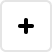
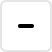
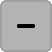
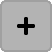
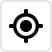
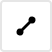
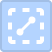
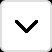
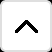
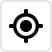
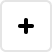
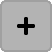
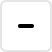
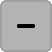
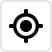
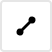
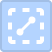
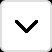
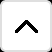
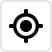

In [1]:
import numpy as np
import pandas as pd
from lets_plot import *
LetsPlot.setup_html()

In [2]:
np.random.seed(42)

In [3]:
t = np.linspace(0, 1, 100)
mean = 1 + np.zeros(2)
cov = np.eye(2)
x, y = np.random.multivariate_normal(mean, cov, t.size).T
df = pd.DataFrame({'t': t, 'x': x, 'y': y})
df = df.melt(id_vars=['t'], value_vars=['x', 'y'])

In [4]:
ggplot(df, aes(x='t', y='value', group='variable')) + \
    geom_point(aes(color='variable'), size=3, alpha=.5) + \
    geom_smooth(aes(color='variable'), size=1, deg=3, span=.3, level=.7, seed=42, 
                labels = smooth_labels()
                .line('\(R\^2=\)@..r2.., \(R_{{adj}}\^2=\)@..adjr2.., ~eq')
                .format('..r2..', '.4f')
                .format('..adjr2..', '.4f')
                .eq(format='.2f')
                .label_y(['top', 'bottom'])
                .inherit_color())

In [5]:
n = 100
x = np.linspace(-2, 2, n)
y = x ** 3 + np.random.normal(size=n)

In [6]:
ggplot({'x': x, 'y': y}, aes(x='x', y='y')) + geom_point() + \
    geom_smooth(color='red', deg=1, labels = smooth_labels().label_y(8).inherit_color()) + \
    geom_smooth(color='green', deg=2, labels = smooth_labels().label_y(6).inherit_color()) + \
    geom_smooth(color='blue', deg=3, labels = smooth_labels().label_y(4).inherit_color())

In [7]:
plot = ggplot({'x': [0, 1.5, 1.7, 2], 'y': [0, 1, 1.8, 4]}, aes('x', 'y')) + geom_point() 

### Default usage
`smooth_labels()` without any parameters or method calls displays the coefficient of determination (R²).

In [8]:
plot + geom_smooth(deg=2, labels = smooth_labels())

When using `line()`, the value is displayed without the left-hand part (label). The user can format the line as desired.

In [9]:
plot + geom_smooth(deg=2, labels = smooth_labels()
                   .line('@..r2..')
                   .line('R\^2=@..r2..')
                   .line('\(R\^2\)=@..r2..'))

Use `format()` to format the values.

In [10]:
plot + geom_smooth(deg=2, labels = smooth_labels()
                   .line('@..adjr2..')
                   .format('..adjr2..', '.3f'))

`size()`

In [11]:
plot + geom_smooth(deg=2, labels = smooth_labels().size(20))

### Formula
Use `~eq` to display the equation.

`~eq` represents the full equation (including the left-hand part, e.g. `y=`) and can be configured with `eq(lhs, rhs, format, threshold)`.

In [12]:
plot + geom_smooth(deg=2, labels = smooth_labels()
                   .line('~eq'))

#### Equation configuration: `eq()`

Parameters `lhs` and `rhs`


In [13]:
gggrid([
    # Replaces 'y' with f(x) on the left-hand side of the equation
    plot + geom_smooth(deg=2, labels=smooth_labels().line('~eq').eq(lhs='f(x)')),
    # Completely removes the left-hand side of the equation
    plot + geom_smooth(deg=2, labels=smooth_labels().line('~eq').eq(lhs='')),
    # Replaces 'x' with 't' on the right-hand side of the equation
    plot + geom_smooth(deg=2, labels=smooth_labels().line('~eq').eq(rhs='t')),
], ncol = 1)


Coefficient formatting

In [14]:
gggrid([
    # The regular format() is applied to all coefficients
    plot + geom_smooth(deg=2, labels=smooth_labels().line('~eq').format('~eq', '.1f')),
    # One format in eq() is applied to all coefficients
    plot + geom_smooth(deg=2, labels=smooth_labels().line('~eq').eq(format='.2f')),
    # You can pass a list to format each coefficient separately.
    # The list length does not have to match the number of coefficients:
    # the last format in the list will be used for any remaining coefficients.
    plot + geom_smooth(deg=2, labels=smooth_labels().line('~eq').eq(format=['.1f', '.3f'])),
])

Parameter `threshold` 

In [15]:
plot + geom_smooth(deg=2, labels=smooth_labels()
                   .line('~eq')
                   .eq(threshold=0.01))

#### Positioning: `label_x()` and `label_y()`

By default, the text is shown in the upper-left corner. To change its position, use `label_x()` and `label_y()`. They accept strings (`left`, `center`, `right`) for `label_x()` and (`top`, `middle`, `bottom`) for `label_y()`, or an exact position in plot coordinates.

In [16]:
gggrid([
    plot + geom_smooth(deg=2, labels = smooth_labels().label_x('center').label_y('middle')), 
    plot + geom_smooth(deg=2, labels = smooth_labels().label_x(0.5).label_y(4))
])

#### Grouping
If the data for `geom_smooth()` is grouped, the statistics are computed separately for each group automatically. If groups are differentiated by color, use `inherit_color()` to make the label text color match the geom_smooth() line color.

By default, group labels are stacked vertically, but you can control the position of each group independently. To do this, pass lists to `label_x()` and `label_y()`.


In [17]:
x = [0, 1.5, 1.7, 2, 0, 1.5, 1.7, 2]
y = [0, 1, 1.8, 4, 0.5, 1.5, 3, 4.5]
g = ['a', 'a', 'a', 'a', 'b', 'b', 'b', 'b']

plot_groups = ggplot({'x': x, 'y': y, 'g': g}, aes('x', 'y')) + geom_point() 

In [18]:
gggrid([
    plot_groups + geom_smooth(aes(x='x', y='y', color='g'), deg=2, labels = smooth_labels().inherit_color()) + ggtitle('Color'),
    plot_groups + geom_smooth(aes(x='x', y='y', linetype='g'), deg=2, labels = smooth_labels().label_x('center').label_y([-4, 6])) + ggtitle('Linetype')
])

#### All supported variables

In [19]:
plot + geom_smooth(deg=2, labels = smooth_labels()
                   .line('n=@..n..')
                   .line('Method: @..method..')                   
                   .line('\(R\^2=\)@..r2..')
                   .line('\(R_{{adj}}\^2=\)@..adjr2..')
                   .line('AIC=@..aic..')
                   .line('BIC=@..bic..')
                   .line('\(F_{{@..df1.., @..df2..}}=\)@..f..')
                   .line('p=@..p..')
                   .line('@..cilevel.. CI [@..cilow.., @..cihigh..]')
                   .format('..cilevel..', '0.0%')
                   .line('~eq')
                   )